In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"adarshgupta07","key":"49728a9ea62ac83c25d4d5f5f613e0ad"}'}

In [ ]:
!pip install kaggle -q
import os, json

os.makedirs('/root/.config/kaggle', exist_ok=True)
kaggle_creds = {
    "username": "tumhara_username",
    "key": "tumhara_api_key"
}
with open('/root/.config/kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

!kaggle datasets download -d currie32/crimes-in-chicago

Dataset URL: https://www.kaggle.com/datasets/currie32/crimes-in-chicago
License(s): unknown
100% 467M/467M [00:09<00:00, 54.4MB/s]



In [ ]:
import zipfile
import os

# Zip file dhundho
print(os.listdir('.'))

['.config', 'crimes-in-chicago.zip', 'sample_data']


In [ ]:
import pandas as pd
df=pd.read_csv('Chicago_Crimes_2012_to_2017.csv')
df.head()

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,3,10508693,HZ250496,05/03/2016 11:40:00 PM,013XX S SAWYER AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,True,...,24.0,29.0,08B,1154907.0,1893681.0,2016,05/10/2016 03:56:50 PM,41.864073,-87.706819,"(41.864073157, -87.706818608)"
1,89,10508695,HZ250409,05/03/2016 09:40:00 PM,061XX S DREXEL AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,...,20.0,42.0,08B,1183066.0,1864330.0,2016,05/10/2016 03:56:50 PM,41.782922,-87.604363,"(41.782921527, -87.60436317)"
2,197,10508697,HZ250503,05/03/2016 11:31:00 PM,053XX W CHICAGO AVE,0470,PUBLIC PEACE VIOLATION,RECKLESS CONDUCT,STREET,False,...,37.0,25.0,24,1140789.0,1904819.0,2016,05/10/2016 03:56:50 PM,41.894908,-87.758372,"(41.894908283, -87.758371958)"
3,673,10508698,HZ250424,05/03/2016 10:10:00 PM,049XX W FULTON ST,0460,BATTERY,SIMPLE,SIDEWALK,False,...,28.0,25.0,08B,1143223.0,1901475.0,2016,05/10/2016 03:56:50 PM,41.885687,-87.749516,"(41.885686845, -87.749515983)"
4,911,10508699,HZ250455,05/03/2016 10:00:00 PM,003XX N LOTUS AVE,0820,THEFT,$500 AND UNDER,RESIDENCE,False,...,28.0,25.0,06,1139890.0,1901675.0,2016,05/10/2016 03:56:50 PM,41.886297,-87.761751,"(41.886297242, -87.761750709)"


In [ ]:
print(df.isnull().sum())

Unnamed: 0                  0
ID                          0
Case Number                 1
Date                        0
Block                       0
IUCR                        0
Primary Type                0
Description                 0
Location Description     1658
Arrest                      0
Domestic                    0
Beat                        0
District                    1
Ward                       14
Community Area             40
FBI Code                    0
X Coordinate            37083
Y Coordinate            37083
Year                        0
Updated On                  0
Latitude                37083
Longitude               37083
Location                37083
dtype: int64


In [ ]:
df = df.dropna(columns=['X Coordinate', 'Y Coordinate', 'Latitude', 'Longitude', 'Location'])
print(df.isnull().sum())

TypeError: DataFrame.dropna() got an unexpected keyword argument 'columns'

In [ ]:
df['Location Description'].fillna(df['Location Description'].mode()[0], inplace=True)
df['Community Area'].fillna(df['Community Area'].mode()[0], inplace=True)

print("Missing values ab:")
print(df.isnull().sum())
print("\nShape:", df.shape)

/tmp/ipykernel_599/4279660016.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Location Description'].fillna(df['Location Description'].mode()[0], inplace=True)
/tmp/ipykernel_599/4279660016.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

Missing values ab:
Unnamed: 0               0
ID                       0
Case Number              1
Date                     0
Block                    0
IUCR                     0
Primary Type             0
Description              0
Location Description     0
Arrest                   0
Domestic                 0
Beat                     0
District                 1
Ward                    14
Community Area           0
FBI Code                 0
Year                     0
Updated On               0
dtype: int64

Shape: (1456714, 18)


In [ ]:
df['Ward'].fillna(df['Community Area'].mode()[0], inplace=True)

/tmp/ipykernel_599/1325578690.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Ward'].fillna(df['Community Area'].mode()[0], inplace=True)


In [ ]:
import pandas as pd

# Reload the original dataframe to get Latitude and Longitude back
df = pd.read_csv('Chicago_Crimes_2012_to_2017.csv')

# Drop only 'X Coordinate', 'Y Coordinate', and 'Location' as requested
df = df.drop(columns=['X Coordinate', 'Y Coordinate', 'Location'])

# Reapply previous fillna operations
df['Location Description'].fillna(df['Location Description'].mode()[0], inplace=True)
df['Community Area'].fillna(df['Community Area'].mode()[0], inplace=True)
df['Ward'].fillna(df['Community Area'].mode()[0], inplace=True)
df['District'].fillna(df['Community Area'].mode()[0], inplace=True)

# Drop the last remaining row with a missing 'Case Number'
df.dropna(inplace=True)

print(df.isnull().sum())
print("\nShape:", df.shape)

/tmp/ipykernel_599/1764561485.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Location Description'].fillna(df['Location Description'].mode()[0], inplace=True)
/tmp/ipykernel_599/1764561485.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[co

Unnamed: 0              0
ID                      0
Case Number             0
Date                    0
Block                   0
IUCR                    0
Primary Type            0
Description             0
Location Description    0
Arrest                  0
Domestic                0
Beat                    0
District                0
Ward                    0
Community Area          0
FBI Code                0
Year                    0
Updated On              0
Latitude                0
Longitude               0
dtype: int64

Shape: (1419631, 20)


In [ ]:
df['District'].fillna(df['Community Area'].mode()[0], inplace=True)

/tmp/ipykernel_599/3819466934.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['District'].fillna(df['Community Area'].mode()[0], inplace=True)


In [ ]:
print(df.isnull().sum())

Unnamed: 0              0
ID                      0
Case Number             1
Date                    0
Block                   0
IUCR                    0
Primary Type            0
Description             0
Location Description    0
Arrest                  0
Domestic                0
Beat                    0
District                0
Ward                    0
Community Area          0
FBI Code                0
Year                    0
Updated On              0
dtype: int64


In [ ]:
print(df.columns.tolist())

['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'Year', 'Updated On']


In [ ]:
print(df.columns.tolist())

['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'Year', 'Updated On', 'Latitude', 'Longitude']


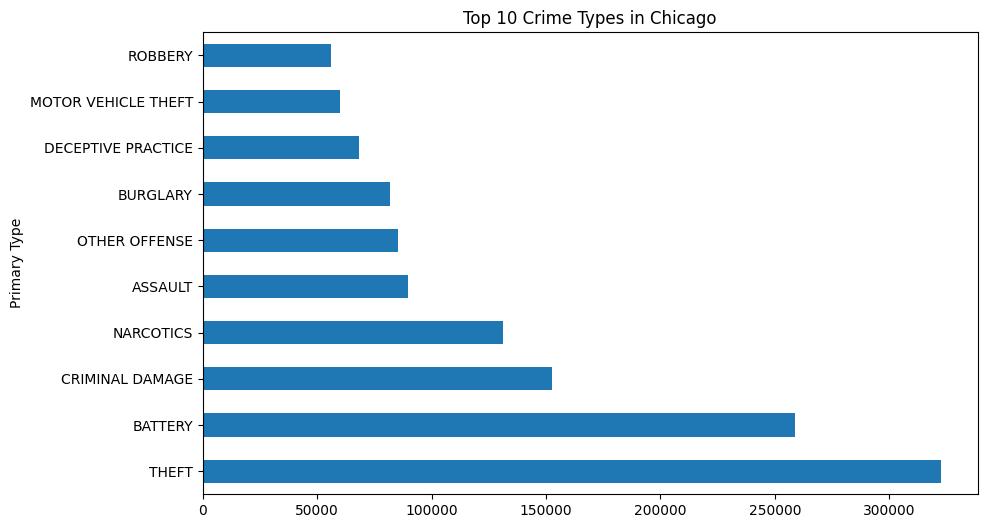

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
df_sample=df.sample(5000,random_state=42)
df['Primary Type'].value_counts().head(10).plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Crime Types in Chicago')
plt.show()

In [ ]:
!pip install folium -q

import folium
from folium.plugins import HeatMap

In [ ]:
chicago_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

# Heatmap data prepare karo
heat_data = df_sample[['Latitude', 'Longitude']].values.tolist()

# Heatmap lagao
HeatMap(heat_data, radius=8).add_to(chicago_map)

# Save karo
chicago_map.save('crime_map.html')
print("Map saved!")

Map saved!


In [ ]:
# Colab mein map dikhao
from IPython.display import IFrame
IFrame('crime_map.html', width=800, height=500)

In [ ]:
from google.colab import files
files.download('crime_map.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pickle

# Crime type encode karo
le = LabelEncoder()
df['Crime_Code'] = le.fit_transform(df['Primary Type'])

# Features
X = df[['Latitude', 'Longitude', 'Year']]
y = df['Crime_Code']

# Sample lo — fast training ke liye
X_sample = X.sample(50000, random_state=42)
y_sample = y[X_sample.index]

# Train karo
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# Save karo
with open('crime_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model saved!")

Model saved!


In [ ]:
app_code = '''
import streamlit as st
import folium
from folium.plugins import HeatMap
import pandas as pd
import pickle
from streamlit_folium import st_folium

# Model load karo
with open('crime_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Data load karo
df = pd.read_csv('Chicago_Crimes_2012_to_2017.csv')
df = df[['Primary Type', 'Latitude', 'Longitude', 'Year']].dropna()

st.title("🗺️ Chicago Crime Hotspot Predictor")
st.write("Real crime data se banaya gaya!")

# Sidebar filters
st.sidebar.header("Filters")
year = st.sidebar.slider("Year", 2012, 2017, 2015)
crime_type = st.sidebar.selectbox("Crime Type", df['Primary Type'].unique())

# Filter data
filtered = df[(df['Year'] == year) & (df['Primary Type'] == crime_type)]
st.write(f"Total crimes: {len(filtered)}")

# Map banao
chicago_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)
heat_data = filtered[['Latitude', 'Longitude']].values.tolist()
HeatMap(heat_data, radius=10).add_to(chicago_map)

# Map dikhao
st_folium(chicago_map, width=700, height=500)

# Top areas
st.subheader("📊 Crime Stats")
st.bar_chart(df[df['Year']==year]['Primary Type'].value_counts().head(10))
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py saved!")

app.py saved!


In [ ]:
!pip install streamlit streamlit-folium -q
!streamlit run app.py &




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.244.134:8501

  Stopping...


In [ ]:
!pip install pyngrok -q
from pyngrok import ngrok

# Tunnel banao
public_url = ngrok.connect(8501)
print("App URL:", public_url)

ERROR:pyngrok.process.ngrok:t=2026-04-13T07:07:38+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [ ]:
from google.colab import files
files.download('app.py')
files.download('crime_model.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle

# Pehle check karo file hai?
import os
print(os.path.exists('crime_model.pkl'))

True


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pickle

# Sirf 10 trees — chhota model!
model_small = RandomForestClassifier(n_estimators=10,
                                     max_depth=5,
                                     random_state=42)
model_small.fit(X_train, y_train)

# Save karo
with open('crime_model_small.pkl', 'wb') as f:
    pickle.dump(model_small, f)

# Size check karo
import os
size = os.path.getsize('crime_model_small.pkl')
print(f"Model size: {size/1024/1024:.2f} MB")


Model size: 0.19 MB


In [ ]:
files.download('crime_model_small.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Colab mein run karo
df_small = df.sample(5000, random_state=42)
df_small.to_csv('chicago_crimes_sample.csv', index=False)

from google.colab import files
files.download('chicago_crimes_sample.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>